## SWE - CppJIT - CUB - SOLUTION

NumPy, JAX, PyOMP, and nanobind each rewrote the same step in a different way,
but nanobind required a separate build: edit the C++, run CMake, restart the
kernel, re-import. CppJIT removes that round-trip: hand it C++ or CUDA source
with `cppjit.cppdef`, and the declared functions are callable from Python
straight away, and NumPy arrays can be passed as pointers with no wrapper code.
In this notebook we write the step as a CUB kernel and run the whole solve on the GPU.

**SOLUTION**

### Table of Contents

1. [Imports and activation](#sec1)
2. [Solve on the GPU with CUB in C++](#sec2)
3. [Acceptance and timing](#sec3)
4. [CuPy baseline](#sec4)
5. [Fusing the CuPy step](#sec5)
6. [Raw CUDA kernel](#sec6)
7. [Scaling: fused vs drop-in vs CPU](#sec7)
8. [Limitation: first-call compile latency](#sec8)

### <a id="sec1"></a>1. Imports and activation

`import cppjit` starts a live CUDA-enabled clang-repl interpreter, so the kernels below run on the GPU.

---

**Quick Docs**

- `cppjit.cppdef(src)`: compile a block of C++ or CUDA source and link it into
  the session. The functions it declares become callable from Python automatically through proxies.
- `cppjit.gbl.<name>(...)`: call a declared C++ function. A contiguous `float64`
  array can be passed through as a `double*`, zero-copy.
- `cppjit.CUDA_ENABLED`: returns `True` if the C++ interpreter was created with CUDA support.

---

**Note.** CppJIT is the successor project to the cppyy Python/C++ bindings generator that originated from the field of high-energy physics.
Based purely on the upstream LLVM compiler infrastructure and the CppInterOp library, CppJIT enables automatic interoperability paradigms and advanced features such as GPU and C++23 support.
This tutorial image bootstraps an alpha version of this package, built from source. A beta release on PyPI is planned for late August 2026.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import swe_core
import cppjit

assert cppjit.CUDA_ENABLED, \
    'This notebook needs the CUDA-enabled tutorial image.'

# Shared problem parameters.
N       = 16384
L       = 10.0
H0      = 1.0
AMP     = 0.1
SIG     = 0.5
CFL     = 0.4
G       = 9.81
N_STEPS = 1000

# Float64 NumPy reference for validation.
h_ref, _ = swe_core.solve_numpy(N, N_STEPS)

### <a id="sec2"></a>2. Solve on the GPU with CUB in C++

Let's solve the same Rusanov step with the CUB library in C++. CUB is a library of architecture-tuned CUDA C++ building blocks: warp-, block-,
and device-level algorithm primitives, shipped with the CUDA Toolkit as part
of CCCL.
The kernel lives in `swe_cub_solver.cpp`. `cppjit.cppdef` compiles it into the session.

---

**Quick Docs**

- `cub::DeviceFor::Bulk(n, op)`: run `op` on the GPU for each index in
  `0..n-1`, so we walk the cells without building an index array.
- `[=] __device__ (long i) { ... }`: a CUDA lambda. It captures the field
  pointers by value and runs on the device.
- `cudaMalloc` / `cudaMemcpy`: explicit device allocation and host-device
  copies, once per solve.

In [2]:
cppjit.cppdef(open(swe_core.SWE_CUB_CPP).read())

def run_swe_gpu(n_cells=N, n_steps=N_STEPS):
    """Run the full SWE solve on the GPU and return the final (h, hu)."""
    cell_dx = L / n_cells
    step_dt = swe_core.fixed_dt(H0 + AMP, cell_dx, cfl=CFL, g=G)
    h, hu = swe_core.bump_ic(n_cells, L=L, h0=H0, amplitude=AMP, sigma=SIG)
    h = np.ascontiguousarray(h); hu = np.ascontiguousarray(hu)
    h_out = np.empty_like(h); hu_out = np.empty_like(hu)
    cppjit.gbl.gpu_swe_solve(h, hu, h_out, hu_out, h.shape[0],
                             cell_dx, step_dt, G, n_steps)
    return h_out, hu_out

### <a id="sec3"></a>3. Acceptance and timing

We run the full solve, check it against the float64 NumPy reference, then
report a time. Cold call cost: clang-repl emits PTX, and the CUDA driver compiles PTX to
SASS for the present GPU at first launch. Saved in timings.json along with warm median runs.

In [3]:
t0 = time.perf_counter()
h_gpu, _ = run_swe_gpu()
cold_s = time.perf_counter() - t0

warm = swe_core.timed_run(run_swe_gpu, warmup=2, repeats=5, label='12_cppjit_gpu_cub')
diff = swe_core.max_diff(h_ref, h_gpu)
swe_core.report_and_verify(warm, diff, tol=1e-12, cold_s=cold_s,
                           n=N, steps=N_STEPS,
                           cold_note='incl. JIT + first PTX->SASS')

swe_core.save_timing(
    warm, grid_str=f'N={N}', tool='cppjit_gpu_cub', hardware='gpu',
    dtype='float64', steps=N_STEPS, cold_s=cold_s, max_diff_vs_numpy=diff)

[12_cppjit_gpu_cub] N=16384 steps=1000 | cold   110.0 ms (incl. JIT + first PTX->SASS) | warm    15.8 ms | max_diff 1.55e-15 < tol 1e-12 | PASS


### <a id="sec4"></a>4. CuPy baseline

Since we are now running on GPU, let's use CuPy as a baseline. Run the same vectorised step as
`swe_core.step_numpy`, but on the device with a drop-in approach (cp.op replaces np.op).

**Q:** the warm time below lands far behind the CUB solve, on the same GPU
with the same arithmetic. Where does the time go? Count the kernel launches
per step with `nsys` below.

In [4]:
import cupy as cp

def step_cupy(h, hu, cell_dx, step_dt, g=G, tol=swe_core.DRY_TOL):
    """swe_core.step_numpy, slice for slice, on the device."""
    hL, hR   = h[:-1],  h[1:]
    huL, huR = hu[:-1], hu[1:]
    h_safe_L = cp.maximum(hL, tol)
    h_safe_R = cp.maximum(hR, tol)
    uL, uR = huL / h_safe_L,        huR / h_safe_R
    cL, cR = cp.sqrt(g * h_safe_L), cp.sqrt(g * h_safe_R)
    a      = cp.maximum(cp.abs(uL) + cL, cp.abs(uR) + cR)
    F_h  = 0.5 * (huL + huR)                            - 0.5 * a * (hR  - hL)
    F_hu = 0.5 * (huL*uL + 0.5*g*hL*hL
                + huR*uR + 0.5*g*hR*hR)                 - 0.5 * a * (huR - huL)
    h_new, hu_new = h.copy(), hu.copy()
    h_new[1:-1]  = h[1:-1]  - (step_dt / cell_dx) * (F_h[1:]  - F_h[:-1])
    hu_new[1:-1] = hu[1:-1] - (step_dt / cell_dx) * (F_hu[1:] - F_hu[:-1])
    return h_new, hu_new

def run_swe_cupy(n_cells=N, n_steps=N_STEPS):
    """Full solve with CuPy; includes the H2D/D2H transfers, like the CUB path."""
    cell_dx = L / n_cells
    step_dt = swe_core.fixed_dt(H0 + AMP, cell_dx, cfl=CFL, g=G)
    h_np, hu_np = swe_core.bump_ic(n_cells, L=L, h0=H0, amplitude=AMP, sigma=SIG)
    h, hu = cp.asarray(h_np), cp.asarray(hu_np)
    for _ in range(n_steps):
        h[0]  =  h[1];   h[-1]  =  h[-2]
        hu[0] = -hu[1];  hu[-1] = -hu[-2]
        h, hu = step_cupy(h, hu, cell_dx, step_dt)
    cp.cuda.Device().synchronize()
    return cp.asnumpy(h), cp.asnumpy(hu)

t0 = time.perf_counter()
h_cupy, _ = run_swe_cupy()
cold_cupy_s = time.perf_counter() - t0

warm_cupy = swe_core.timed_run(run_swe_cupy, warmup=2, repeats=5, label='12_cupy')
diff_cupy = swe_core.max_diff(h_ref, h_cupy)
swe_core.report_and_verify(warm_cupy, diff_cupy, tol=1e-12, cold_s=cold_cupy_s,
                           n=N, steps=N_STEPS,
                           cold_note='incl. NVRTC kernel compiles')

swe_core.save_timing(
    warm_cupy, grid_str=f'N={N}', tool='cupy', hardware='gpu',
    dtype='float64', steps=N_STEPS, cold_s=cold_cupy_s,
    max_diff_vs_numpy=diff_cupy)


[12_cupy] N=16384 steps=1000 | cold   287.7 ms (incl. NVRTC kernel compiles) | warm   269.5 ms | max_diff 0.00e+00 < tol 1e-12 | PASS


**Note.** The cold call doesn't actually compile anything. NVRTC builds CuPy's
own operator kernels (such as `cupy_sqrt__float64...`), and the cubins land
in an on-disk cache (`CUPY_CACHE_DIR`) that persists across sessions, so a
warm cache hides the compile cost. To record it, point `CUPY_CACHE_DIR` at an
empty directory before the `cupy` import and re-run.

**Count the kernel launches.** This tutorial image ships Nsight Systems. The cell
below profiles a short solve of each GPU path and sums kernel instances
per step.

---

**Quick Docs**

- `nsys profile -o <name> python script.py`: record a timeline;
  `--python-sampling=true` adds interpreter backtraces.
- `nsys stats --report cuda_gpu_kern_sum <name>.nsys-rep`: kernel
  instance counts per name.

In [5]:
%%writefile swe_launch_probe.py
import sys
import numpy as np
import swe_core

mode, N, steps = sys.argv[1], int(sys.argv[2]), int(sys.argv[3])
L = 10.0; dx = L / N; dt = swe_core.fixed_dt(1.1, dx)
h, hu = swe_core.bump_ic(N, L=L)
if mode == 'cub':
    import cppjit
    assert cppjit.CUDA_ENABLED
    cppjit.cppdef(open(swe_core.SWE_CUB_CPP).read())
    ho, huo = np.empty_like(h), np.empty_like(hu)
    cppjit.gbl.gpu_swe_solve(h, hu, ho, huo, h.shape[0], dx, dt, 9.81, steps)
else:
    import cupy as cp
    gh, ghu = cp.asarray(h), cp.asarray(hu)
    for _ in range(steps):
        gh[0] = gh[1]; gh[-1] = gh[-2]; ghu[0] = -ghu[1]; ghu[-1] = -ghu[-2]
        hL, hR = gh[:-1], gh[1:]; huL, huR = ghu[:-1], ghu[1:]
        hsL = cp.maximum(hL, 1e-6); hsR = cp.maximum(hR, 1e-6)
        uL, uR = huL / hsL, huR / hsR
        cL, cR = cp.sqrt(9.81 * hsL), cp.sqrt(9.81 * hsR)
        a = cp.maximum(cp.abs(uL) + cL, cp.abs(uR) + cR)
        F_h = 0.5 * (huL + huR) - 0.5 * a * (hR - hL)
        F_hu = (0.5 * (huL*uL + 0.5*9.81*hL*hL + huR*uR + 0.5*9.81*hR*hR)
                - 0.5 * a * (huR - huL))
        gh2, ghu2 = gh.copy(), ghu.copy()
        gh2[1:-1]  = gh[1:-1]  - (dt/dx) * (F_h[1:]  - F_h[:-1])
        ghu2[1:-1] = ghu[1:-1] - (dt/dx) * (F_hu[1:] - F_hu[:-1])
        gh, ghu = gh2, ghu2
    cp.cuda.Device().synchronize()

Overwriting swe_launch_probe.py


In [6]:
PROF_STEPS = 20
!nsys profile --python-sampling=true --force-overwrite true -o launch_cub python swe_launch_probe.py cub {N} {PROF_STEPS}
!nsys profile --python-sampling=true --force-overwrite true -o launch_cupy python swe_launch_probe.py cupy {N} {PROF_STEPS}

Generating '/tmp/nsys-report-77b9.qdstrm'



[1/1] [0%                          ] launch_cub.nsys-rep


[1/1] [0%                          ] launch_cub.nsys-rep
[1/1] [======35%                   ] launch_cub.nsys-rep
[1/1] [=======39%                  ] launch_cub.nsys-rep
[1/1] [=========43%                ] launch_cub.nsys-rep
[1/1] [=========44%                ] launch_cub.nsys-rep


[1/1] [=========45%                ] launch_cub.nsys-rep
[1/1] [=========46%                ] launch_cub.nsys-rep
[1/1] [==========48%               ] launch_cub.nsys-rep
[1/1] [===========51%              ] launch_cub.nsys-rep
[1/1] [===========52%              ] launch_cub.nsys-rep
[1/1] [============55%             ] launch_cub.nsys-rep
[1/1] [=============59%            ] launch_cub.nsys-rep
[1/1] [==============63%           ] launch_cub.nsys-rep
[1/1] [===============66%          ] launch_cub.nsys-rep
[1/1] [================70%         ] launch_cub.nsys-rep
[1/1] [================71%         ] launch_cub.nsys-rep
[1/1] [=================73%        ] launch_cub.nsys-rep
[1/1] [=================74%        ] launch_cub.nsys-rep
[1/1] [==================78%       ] launch_cub.nsys-rep
[1/1] [===================79%      ] launch_cub.nsys-rep
[1/1] [===================81%      ] launch_cub.nsys-rep
[1/1] [=====================88%    ] launch_cub.nsys-rep
[1/1] [=======================


[1/1] [========================100%] launch_cub.nsys-rep
Generated:
	/accelerated-computing-hub/tutorials/pyhpc/notebooks/solutions/launch_cub.nsys-rep


...


[1/1] [0%                          ] launch_cupy.nsys-rep


[1/1] [0%                          ] launch_cupy.nsys-rep


[1/1] [==20%                       ] launch_cupy.nsys-rep
[1/1] [==21%                       ] launch_cupy.nsys-rep
[1/1] [====28%                     ] launch_cupy.nsys-rep
[1/1] [======35%                   ] launch_cupy.nsys-rep
[1/1] [=======36%                  ] launch_cupy.nsys-rep
[1/1] [=======37%                  ] launch_cupy.nsys-rep
[1/1] [=======38%                  ] launch_cupy.nsys-rep
[1/1] [=======39%                  ] launch_cupy.nsys-rep
[1/1] [=========43%                ] launch_cupy.nsys-rep


[1/1] [=========44%                ] launch_cupy.nsys-rep
[1/1] [===========51%              ] launch_cupy.nsys-rep
[1/1] [===========52%              ] launch_cupy.nsys-rep
[1/1] [===========53%              ] launch_cupy.nsys-rep
[1/1] [============54%             ] launch_cupy.nsys-rep
[1/1] [============55%             ] launch_cupy.nsys-rep
[1/1] [============56%             ] launch_cupy.nsys-rep
[1/1] [============57%             ] launch_cupy.nsys-rep
[1/1] [==============63%           ] launch_cupy.nsys-rep
[1/1] [===============67%          ] launch_cupy.nsys-rep
[1/1] [================71%         ] launch_cupy.nsys-rep
[1/1] [=================72%        ] launch_cupy.nsys-rep
[1/1] [=================74%        ] launch_cupy.nsys-rep
[1/1] [==================76%       ] launch_cupy.nsys-rep
[1/1] [========================100%] launch_cupy.nsys-rep


[1/1] [========================100%] launch_cupy.nsys-rep
Generated:
	/accelerated-computing-hub/tutorials/pyhpc/notebooks/solutions/launch_cupy.nsys-rep


In [7]:
for mode in ('cub', 'cupy'):
    rows = !nsys stats --force-export=true --report cuda_gpu_kern_sum launch_{mode}.nsys-rep
    kern = [ln for ln in rows if ln.strip()[:1].isdigit()]
    total = sum(int(ln.split()[2]) for ln in kern)
    if total == 0:
        raise RuntimeError(f'no kernels recorded for {mode}; re-run the profile cell')
    print(f'  {mode:>6}: {total:>4} kernel launches over {PROF_STEPS} steps '
          f'= {total / PROF_STEPS:5.1f} kernels/step')

     cub:   40 kernel launches over 20 steps =   2.0 kernels/step


    cupy:  860 kernel launches over 20 steps =  43.0 kernels/step


### <a id="sec5"></a>5. Fusing the CuPy step

`cupy.ElementwiseKernel` fuses the whole step into one CUDA C kernel,
one thread per cell. Each thread derives its ghost values, computes
its two face fluxes, and writes its update. This should give us one launch
per step, with no Python round-trip. Since neighbouring cells share faces,
every interior flux is computed twice; storing them instead would require a
second pass and launch, as in the earlier CUB case.

---

**Quick Docs**

- `cp.ElementwiseKernel(in_params, out_params, operation, name, preamble=...)`:
  compiles a CUDA C elementwise kernel on first call (NVRTC). `raw float64 x`
  passes an array with explicit indexing (`x[j]`) instead of an implicit
  per-element view; `size=` sets the launch size.
- `preamble`: pass CUDA C `__device__` helpers.

In [8]:
_RUSANOV_DEV = r'''
__device__ void rusanov_face(double hL, double hR, double huL, double huR,
                             double g, double& Fh, double& Fhu) {
    const double DRY  = 1e-6;
    const double hL_s = hL > DRY ? hL : DRY;
    const double hR_s = hR > DRY ? hR : DRY;
    const double uL = huL / hL_s, uR = huR / hR_s;
    const double cL = sqrt(g * hL_s), cR = sqrt(g * hR_s);
    const double a  = fmax(fabs(uL) + cL, fabs(uR) + cR);
    Fh  = 0.5 * (huL + huR) - 0.5 * a * (hR - hL);
    Fhu = 0.5 * (huL * uL + 0.5 * g * hL * hL + huR * uR + 0.5 * g * hR * hR)
        - 0.5 * a * (huR - huL);
}
'''

step_cupy_fused = cp.ElementwiseKernel(
    'raw float64 h, raw float64 hu, int64 n, float64 inv, float64 g',
    'raw float64 h_new, raw float64 hu_new',
    '''
    const long j = i + 1;                              // interior cell
    const double hW  = (j == 1) ?  h[1]  : h[j - 1];   // reflective ghosts,
    const double huW = (j == 1) ? -hu[1] : hu[j - 1];  // derived in-kernel
    const double hE  = (j == n) ?  h[n]  : h[j + 1];
    const double huE = (j == n) ? -hu[n] : hu[j + 1];
    double Fw_h, Fw_hu, Fe_h, Fe_hu;
    rusanov_face(hW,   h[j], huW,   hu[j], g, Fw_h, Fw_hu);
    rusanov_face(h[j], hE,   hu[j], huE,   g, Fe_h, Fe_hu);
    h_new[j]  = h[j]  - inv * (Fe_h  - Fw_h);
    hu_new[j] = hu[j] - inv * (Fe_hu - Fw_hu);
    if (j == 1) { h_new[0] = h[1]; hu_new[0] = -hu[1]; }
    if (j == n) { h_new[n + 1] = h[n]; hu_new[n + 1] = -hu[n]; }
    ''', 'swe_step_fused', preamble=_RUSANOV_DEV)

def run_swe_cupy_fused(n_cells=N, n_steps=N_STEPS):
    """Full solve with hand-fused CuPy kernel: one launch per step."""
    cell_dx = L / n_cells
    step_dt = swe_core.fixed_dt(H0 + AMP, cell_dx, cfl=CFL, g=G)
    h_np, hu_np = swe_core.bump_ic(n_cells, L=L, h0=H0, amplitude=AMP, sigma=SIG)
    h, hu = cp.asarray(h_np), cp.asarray(hu_np)
    h2, hu2 = cp.empty_like(h), cp.empty_like(hu)
    inv = step_dt / cell_dx
    for _ in range(n_steps):
        step_cupy_fused(h, hu, n_cells, inv, G, h2, hu2, size=n_cells)
        h, hu, h2, hu2 = h2, hu2, h, hu
    cp.cuda.Device().synchronize()
    return cp.asnumpy(h), cp.asnumpy(hu)

t0 = time.perf_counter()
h_fused, _ = run_swe_cupy_fused()
cold_fused_s = time.perf_counter() - t0

warm_fused = swe_core.timed_run(run_swe_cupy_fused, warmup=2, repeats=5,
                                label='12_cupy_fused')
diff_fused = swe_core.max_diff(h_ref, h_fused)
swe_core.report_and_verify(warm_fused, diff_fused, tol=1e-12, cold_s=cold_fused_s,
                           n=N, steps=N_STEPS,
                           cold_note='incl. NVRTC compile of fused kernel')

swe_core.save_timing(
    warm_fused, grid_str=f'N={N}', tool='cupy_fused', hardware='gpu',
    dtype='float64', steps=N_STEPS, cold_s=cold_fused_s,
    max_diff_vs_numpy=diff_fused)


[12_cupy_fused] N=16384 steps=1000 | cold     9.9 ms (incl. NVRTC compile of fused kernel) | warm     8.9 ms | max_diff 1.33e-15 < tol 1e-12 | PASS


### <a id="sec6"></a>6. Raw CUDA kernel

CppJIT is not tied to CUB: the same session can declare a `__global__`
kernel and launch it directly, with no cub dispatch.
`swe_raw_cuda_solver.cpp` rewrites our GPU solver in CUDA C++.

The raw launch has real costs: you size the launch yourself, write the
index guard, and give up CUB's algorithm libraries, autotuning and abstractions.

---

**Quick Docs**

- `__global__ void kernel(...)`: a CUDA kernel; each thread computes its index
  from `blockIdx`/`blockDim`/`threadIdx` and guards the range.
- `kernel<<<grid, block>>>(args)`: launch syntax — a thin driver call. cppjit
  compiles and registers the kernel live (same clang-repl session as CUB).
- Launch shape: 256-thread blocks, `grid = ceil(N / 256)`, try tuning if time permits.

In [ ]:
# Load and compile the raw-kernel solve.
cppjit.cppdef(open(swe_core.SWE_RAW_CPP).read())

def run_swe_gpu_raw(n_cells=N, n_steps=N_STEPS):
    """Full SWE solve with CUDA C++ (two launches/step)."""
    cell_dx = L / n_cells
    step_dt = swe_core.fixed_dt(H0 + AMP, cell_dx, cfl=CFL, g=G)
    h, hu = swe_core.bump_ic(n_cells, L=L, h0=H0, amplitude=AMP, sigma=SIG)
    h = np.ascontiguousarray(h); hu = np.ascontiguousarray(hu)
    h_out = np.empty_like(h); hu_out = np.empty_like(hu)
    cppjit.gbl.gpu_swe_solve_raw(h, hu, h_out, hu_out, h.shape[0],
                                 cell_dx, step_dt, G, n_steps)
    return h_out, hu_out

t0 = time.perf_counter()
h_raw, _ = run_swe_gpu_raw()
cold_raw_s = time.perf_counter() - t0

warm_raw = swe_core.timed_run(run_swe_gpu_raw, warmup=2, repeats=5,
                              label='12_cppjit_gpu_raw')
diff_raw = swe_core.max_diff(h_ref, h_raw)
swe_core.report_and_verify(warm_raw, diff_raw, tol=1e-12, cold_s=cold_raw_s,
                           n=N, steps=N_STEPS,
                           cold_note='incl. JIT + first PTX->SASS compilation')

swe_core.save_timing(
    warm_raw, grid_str=f'N={N}', tool='cppjit_gpu_raw', hardware='gpu',
    dtype='float64', steps=N_STEPS, cold_s=cold_raw_s,
    max_diff_vs_numpy=diff_raw)


[12_cppjit_gpu_raw] N=16384 steps=1000 | cold    24.6 ms (incl. JIT + first PTX->SASS) | warm     9.5 ms | max_diff 1.55e-15 < tol 1e-12 | PASS


### <a id="sec7"></a>7. Scaling: fused vs drop-in vs CPU

The sweep below times all five paths across grid sizes and plots throughput.

N=    1024   CUB      73   raw-CUDA     124   CuPy       4   CuPy-fused     169   NumPy     41   Mcells/s


N=    4096   CUB     255   raw-CUDA     447   CuPy      15   CuPy-fused     674   NumPy     82   Mcells/s


N=   16384   CUB     974   raw-CUDA    1555   CuPy      61   CuPy-fused    1695   NumPy    104   Mcells/s


N=   65536   CUB    1912   raw-CUDA    2083   CuPy     241   CuPy-fused    2407   NumPy    116   Mcells/s


N=  262144   CUB    1901   raw-CUDA    2600   CuPy     896   CuPy-fused    2513   NumPy     42   Mcells/s


N= 1048576   CUB    2295   raw-CUDA    3103   CuPy    1712   CuPy-fused    2841   NumPy     60   Mcells/s


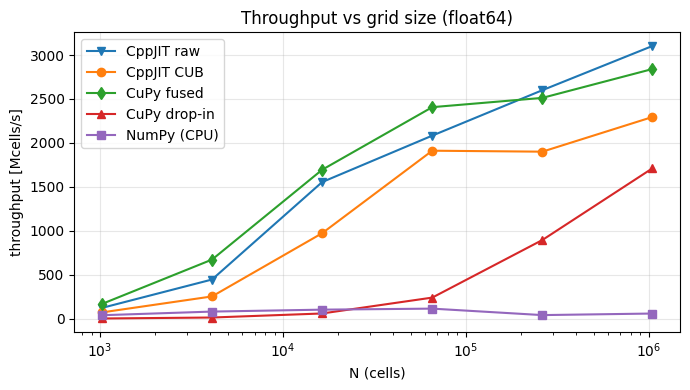

In [ ]:
# Sweep the grid size and compare all five paths on throughput.
SWEEP_N = [1024, 4096, 16384, 65536, 262144, 1048576]
SWEEP_STEPS = 200

cub_rate, raw_rate, cupy_rate, fused_rate, npy_rate = [], [], [], [], []
for n_cells in SWEEP_N:
    t = swe_core.timed_run(run_swe_gpu, n_cells, SWEEP_STEPS, warmup=1, repeats=3)
    rw = swe_core.timed_run(run_swe_gpu_raw, n_cells, SWEEP_STEPS, warmup=1, repeats=3)
    c = swe_core.timed_run(run_swe_cupy, n_cells, SWEEP_STEPS, warmup=1, repeats=3)
    f = swe_core.timed_run(run_swe_cupy_fused, n_cells, SWEEP_STEPS, warmup=1, repeats=3)
    n = swe_core.timed_run(swe_core.solve_numpy, n_cells, SWEEP_STEPS, warmup=1, repeats=3)
    mc = lambda r: n_cells * SWEEP_STEPS / r["median_s"] / 1e6
    cub_rate.append(mc(t)); raw_rate.append(mc(rw)); cupy_rate.append(mc(c))
    fused_rate.append(mc(f)); npy_rate.append(mc(n))
    print(f'N={n_cells:>8}   CUB {cub_rate[-1]:7.0f}   raw-CUDA {raw_rate[-1]:7.0f}   '
          f'CuPy {cupy_rate[-1]:7.0f}   CuPy-fused {fused_rate[-1]:7.0f}   '
          f'NumPy {npy_rate[-1]:6.0f}   Mcells/s')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(SWEEP_N, raw_rate,    "v-", label="CppJIT raw")
ax.plot(SWEEP_N, cub_rate, "o-", label="CppJIT CUB")
ax.plot(SWEEP_N, fused_rate,  "d-", label="CuPy fused")
ax.plot(SWEEP_N, cupy_rate,   "^-", label="CuPy drop-in")
ax.plot(SWEEP_N, npy_rate,    "s-", label="NumPy (CPU)")
ax.set_xscale("log")
ax.set_xlabel("N (cells)")
ax.set_ylabel("throughput [Mcells/s]")
ax.set_title("Throughput vs grid size (float64)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [11]:
# Rates across the shared size range, for the synthesis notebook (14).
for _stage, _fn in (('12_cppjit_gpu_cub', run_swe_gpu),
                    ('12_cppjit_gpu_raw', run_swe_gpu_raw),
                    ('12_cupy', run_swe_cupy),
                    ('12_cupy_fused', run_swe_cupy_fused)):
    swe_core.save_sweep(_stage, _fn)

In [ ]:
# End-to-end cost breakdown at the largest sweep size, for the synthesis notebook (14).
BN, BSTEPS = swe_core.SWEEP_SIZES[-1]

t0 = time.perf_counter()
for _ in range(3):
    h_b, hu_b = swe_core.bump_ic(BN, L=L, h0=H0, amplitude=AMP, sigma=SIG)
ic_s = (time.perf_counter() - t0) / 3

# H2D + D2H of the two state arrays, as every GPU path here does.
d_h, d_hu = cp.asarray(h_b), cp.asarray(hu_b)   # warm the pool
cp.cuda.Device().synchronize()
t0 = time.perf_counter()
for _ in range(3):
    d_h, d_hu = cp.asarray(h_b), cp.asarray(hu_b)
    _, _ = cp.asnumpy(d_h), cp.asnumpy(d_hu)
transfer_s = (time.perf_counter() - t0) / 3

for _stage, _fn in (('12_cppjit_gpu_cub', run_swe_gpu),
                    ('12_cppjit_gpu_raw', run_swe_gpu_raw),
                    ('12_cupy', run_swe_cupy),
                    ('12_cupy_fused', run_swe_cupy_fused)):
    bd = swe_core.breakdown_run(_fn, BN, BSTEPS, ic_s, transfer_s)
    swe_core.save_breakdown(_stage, bd, BN, BSTEPS)
    print(f"{_stage:<20} total {bd['total_s'] * 1e3:7.0f} ms   "
          f"compute {100 * bd['compute_s'] / bd['total_s']:3.0f}%")

Takeaways:

- At small `N` per-step host costs dominate: CuPy drop-in does not pass
  NumPy until the grid exceeds 16K cells. The fused kernel clears the CPU
  from the start.
- The raw CUDA dispatch with CppJIT and fused-CuPy kernel meet at the top
  of the sweep. CUB runs the same two passes but trails.
- The fast paths top out at the fp64 `sqrt`/divide throughput ceiling:
  fp64 runs slower than the fp32 rate, so these kernels move only a few percent
  of the measured bandwidth roof.

### <a id="sec8"></a>8. Limitation: first-call compile latency

CppJIT gives us C++ and CUDA as a notebook language: edit a cell, run it,
call it from Python. The main cost is compilation at first use: `cppdef`
parses the source when it is declared, and the first call pays lazy codegen
plus the driver's PTX-to-SASS translation.

**Recap.**

- `cppjit.cppdef` compiles C++ or CUDA in the running session; `cppjit.gbl`
  calls it with NumPy arrays as pointers.
- The same Rusanov step runs on the GPU with CUB, the data kept resident
  across the time loop.
- Only the drop-in CuPy path trails NumPy at small grids; the fused paths
  clear the CPU from the first size. The win over drop-in is launch traffic:
  43 kernels/step vs one or two.
- The fused CuPy kernel is a fragment compiled inside CuPy's
  generated wrapper, file or string; CppJIT compiles standard C++
  translation units.

Next: `13__swe__mpi4py.ipynb` distributes the same solve across MPI ranks:
slab decomposition and halo exchange.